Import Datasets and libraries

In [2]:
!pip install bubbly chart_studio pandas numpy seaborn

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.graph_objects as go


In [21]:
happy_df = pd.read_csv('/content/happiness_report.csv')
happy_df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [22]:
len(happy_df)

156

In [23]:
happy_df.tail()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
155,156,South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091


Understanding Data and perform exploratory data analysis

In [24]:
happy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


Checking the number of non-null values in the dataframe

In [25]:
happy_df.isnull().sum()

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [26]:
happy_df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [27]:
happy_df.duplicated().sum()

np.int64(0)

<Figure size 2000x2000 with 0 Axes>

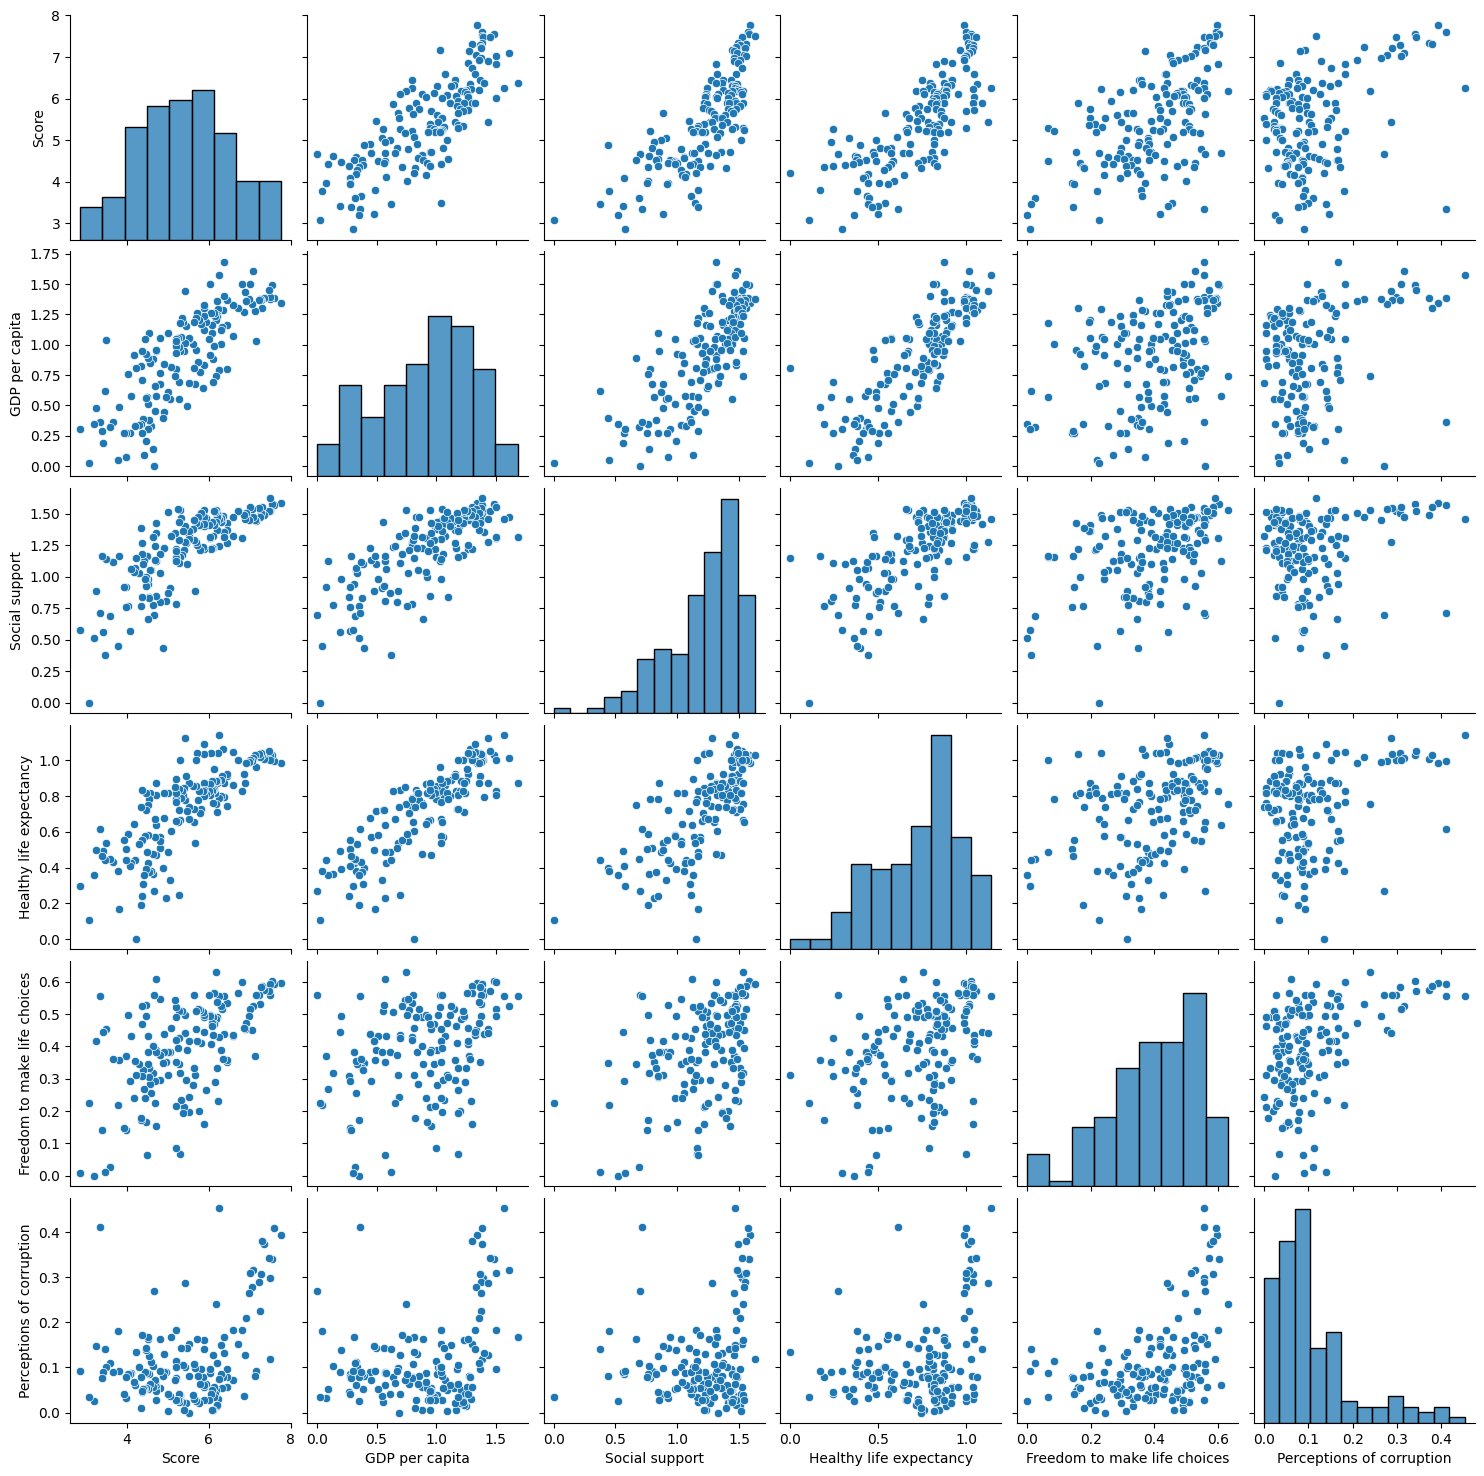

In [28]:
fig= plt.figure(figsize=(20,20))
sns.pairplot(happy_df[
    ['Score',
     'GDP per capita',
     'Social support',
     'Healthy life expectancy',
     'Freedom to make life choices',
     'Perceptions of corruption']
])

/tmp/ipython-input-330/2010640755.py:8: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/tmp/ipython-input-330/2010640755.py:8: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/tmp/ipython-input-330/2010640755.py:8: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your

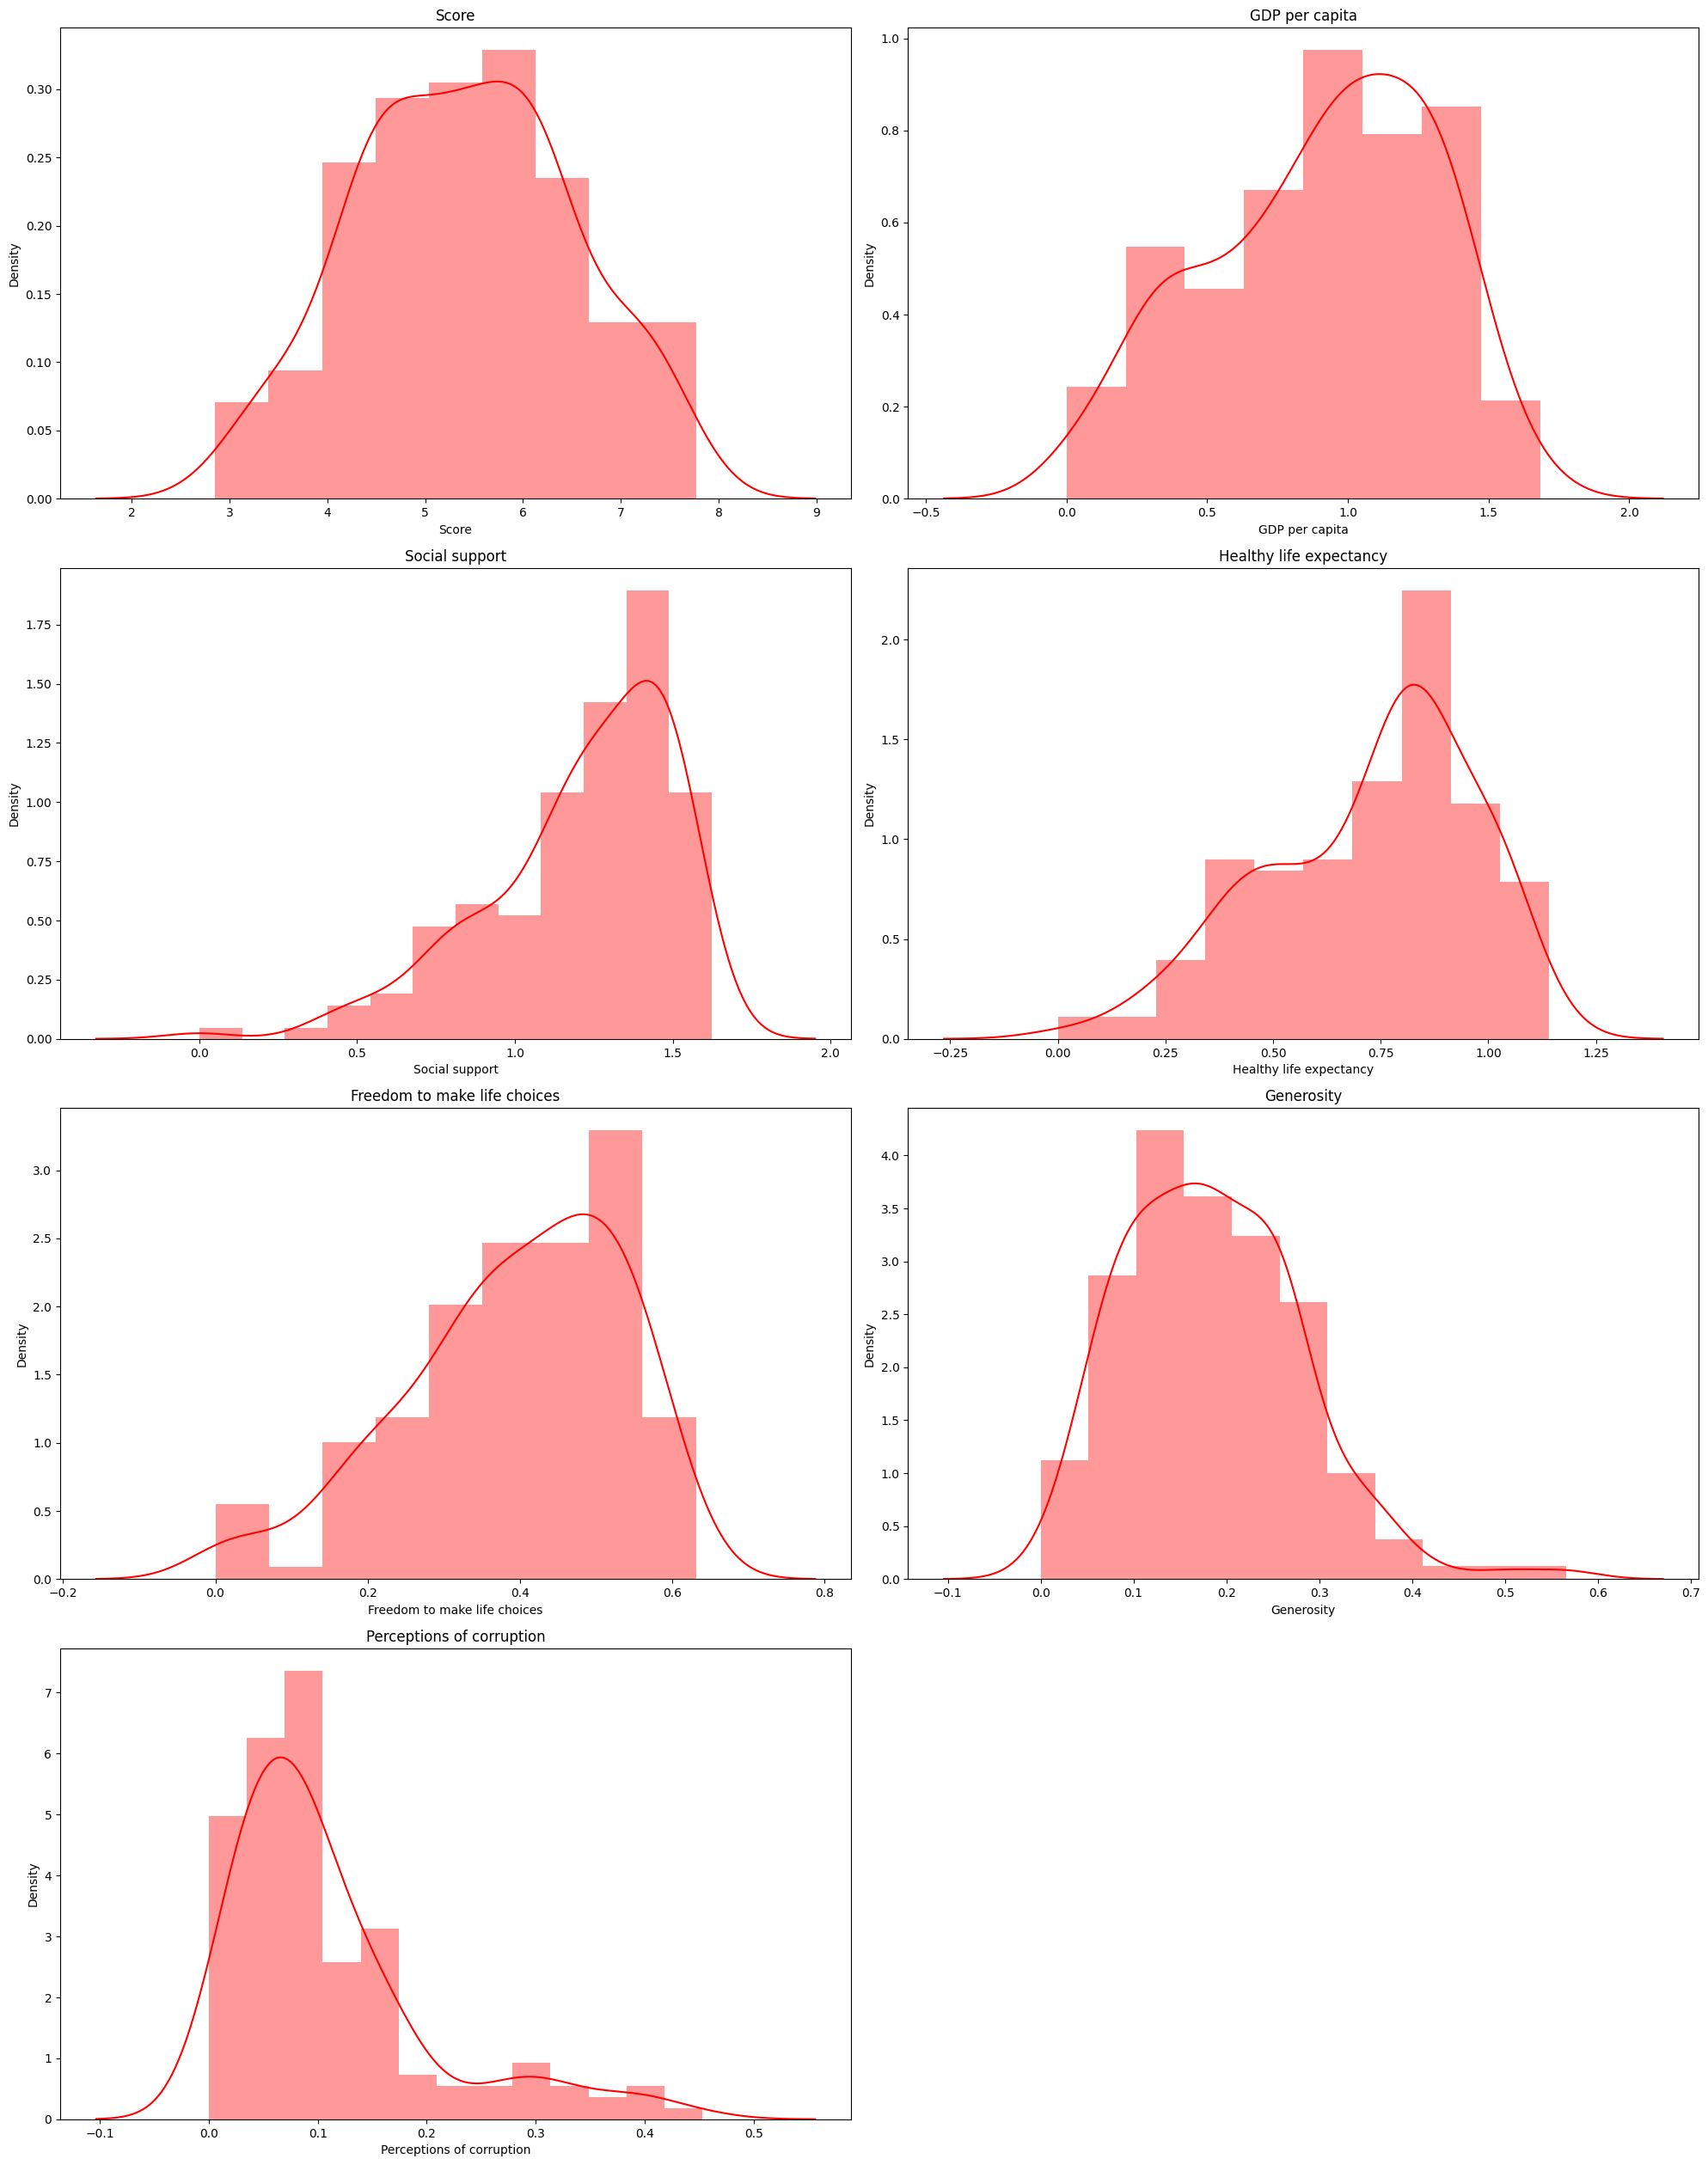

In [29]:
columns = ['Score','GDP per capita', 'Social support', 'Healthy life expectancy',
    'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption']

plt.figure(figsize=(20,50))
for i in range(len(columns)):
  plt.subplot(8,2,i+1)
  sns.distplot(happy_df[columns[i]], color='r')
  plt.title(columns[i])

plt.tight_layout()


In [31]:
corr_matrix=happy_df.select_dtypes(include="number").corr()
corr_matrix

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Overall rank,1.000000,-0.989096,-0.801947,-0.767465,-0.787411,-0.546606,-0.047993,-0.351959
Score,-0.989096,1.000000,0.793883,0.777058,0.779883,0.566742,0.075824,0.385613
GDP per capita,-0.801947,0.793883,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
Social support,-0.767465,0.777058,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
Healthy life expectancy,-0.787411,0.779883,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
Freedom to make life choices,-0.546606,0.566742,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
Generosity,-0.047993,0.075824,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
Perceptions of corruption,-0.351959,0.385613,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


In [32]:
fig=px.scatter(happy_df, x='GDP per capita', y='Score')

In [33]:
fig.show()

In [34]:
fig=px.scatter(happy_df, x='Freedom to make life choices', y='Score', size='Overall rank', color="Country or region", hover_name="Country or region", trendline="ols")

fig.update_layout(title_text="Happiness Score vs Freedom to make life choices")
fig.show()

In [35]:
df_seg= happy_df.drop(columns=['Overall rank', 'Country or region', 'Score'])
df_seg

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1.340,1.587,0.986,0.596,0.153,0.393
1,1.383,1.573,0.996,0.592,0.252,0.410
2,1.488,1.582,1.028,0.603,0.271,0.341
3,1.380,1.624,1.026,0.591,0.354,0.118
4,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...
151,0.359,0.711,0.614,0.555,0.217,0.411
152,0.476,0.885,0.499,0.417,0.276,0.147
153,0.350,0.517,0.361,0.000,0.158,0.025
154,0.026,0.000,0.105,0.225,0.235,0.035


In [36]:
scalar= StandardScaler()
scaled_data= scalar.fit_transform(df_seg)

In [37]:
scaled_data.shape

(156, 6)

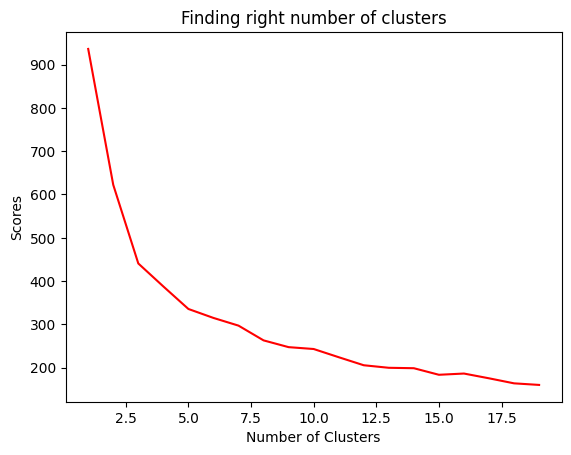

In [38]:
Scores=[]
range_values=range(1,20)

for i in range_values:
  kmeans=KMeans(n_clusters=i)
  kmeans.fit(scaled_data)
  Scores.append(kmeans.inertia_)

plt.plot(range_values, Scores, color='r')
plt.title('Finding right number of clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Scores')
plt.show()

In [39]:
kmeans=KMeans(3)
kmeans.fit(scaled_data)

KMeans(n_clusters=3)

In [41]:
kmeans.cluster_centers_.shape

(3, 6)

In [43]:
kmeans.cluster_centers_

array([[ 0.33840122,  0.34041826,  0.38387917, -0.07257391, -0.54376011,
        -0.43828352],
       [-1.2737923 , -1.15083343, -1.25977929, -0.51571571,  0.2553247 ,
        -0.10543818],
       [ 1.0440483 ,  0.84045675,  0.88671774,  1.04395863,  1.20151704,
         1.46865179]])

In [44]:
cluster_centers=pd.DataFrame(data=kmeans.cluster_centers_, columns=[df_seg.columns])
cluster_centers

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,0.338401,0.340418,0.383879,-0.072574,-0.543760,-0.438284
1,-1.273792,-1.150833,-1.259779,-0.515716,0.255325,-0.105438
2,1.044048,0.840457,0.886718,1.043959,1.201517,1.468652


In [47]:
cluster_centers=scalar.inverse_transform(cluster_centers)
cluster_centers=pd.DataFrame(data=cluster_centers, columns=[df_seg.columns])
cluster_centers

,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1.428522,1.685863,0.947919,0.456438,0.203598,0.121641
1,1.327561,1.646308,0.924813,0.455147,0.204282,0.121919
2,1.472711,1.699127,0.954988,0.459692,0.205092,0.123236


In [51]:
labels=kmeans.labels_

In [52]:
labels.shape

(156,)

In [53]:
y_kmeans = kmeans.fit_predict(scaled_data)
y_kmeans

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 2, 1, 2, 2, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2, 1,
       2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1, 0, 2,
       1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       2, 2], dtype=int32)

In [54]:
happy_df_cluster = pd.concat([happy_df, pd.DataFrame({'cluster':labels})], axis = 1)
happy_df_cluster

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,cluster
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,2
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,2
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,2
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,2
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,2
...,...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411,1
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147,1
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025,1
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035,1


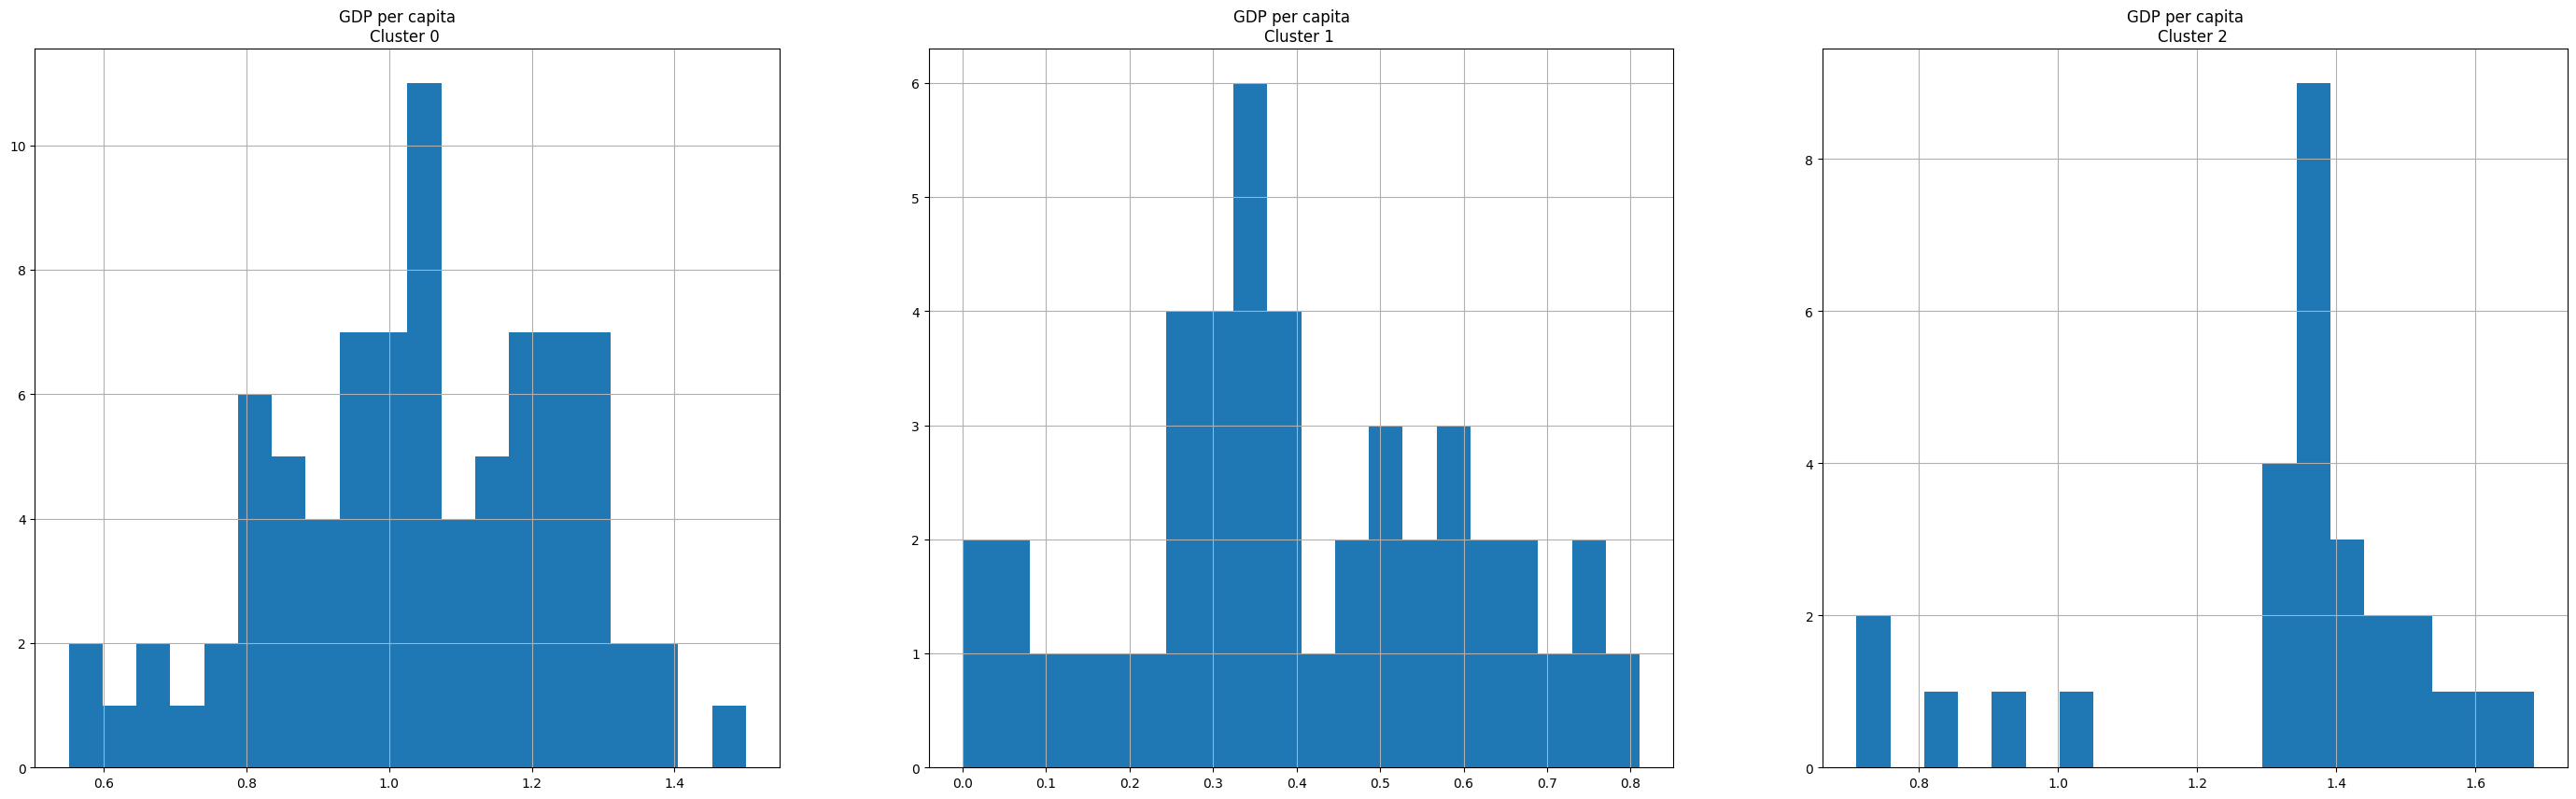

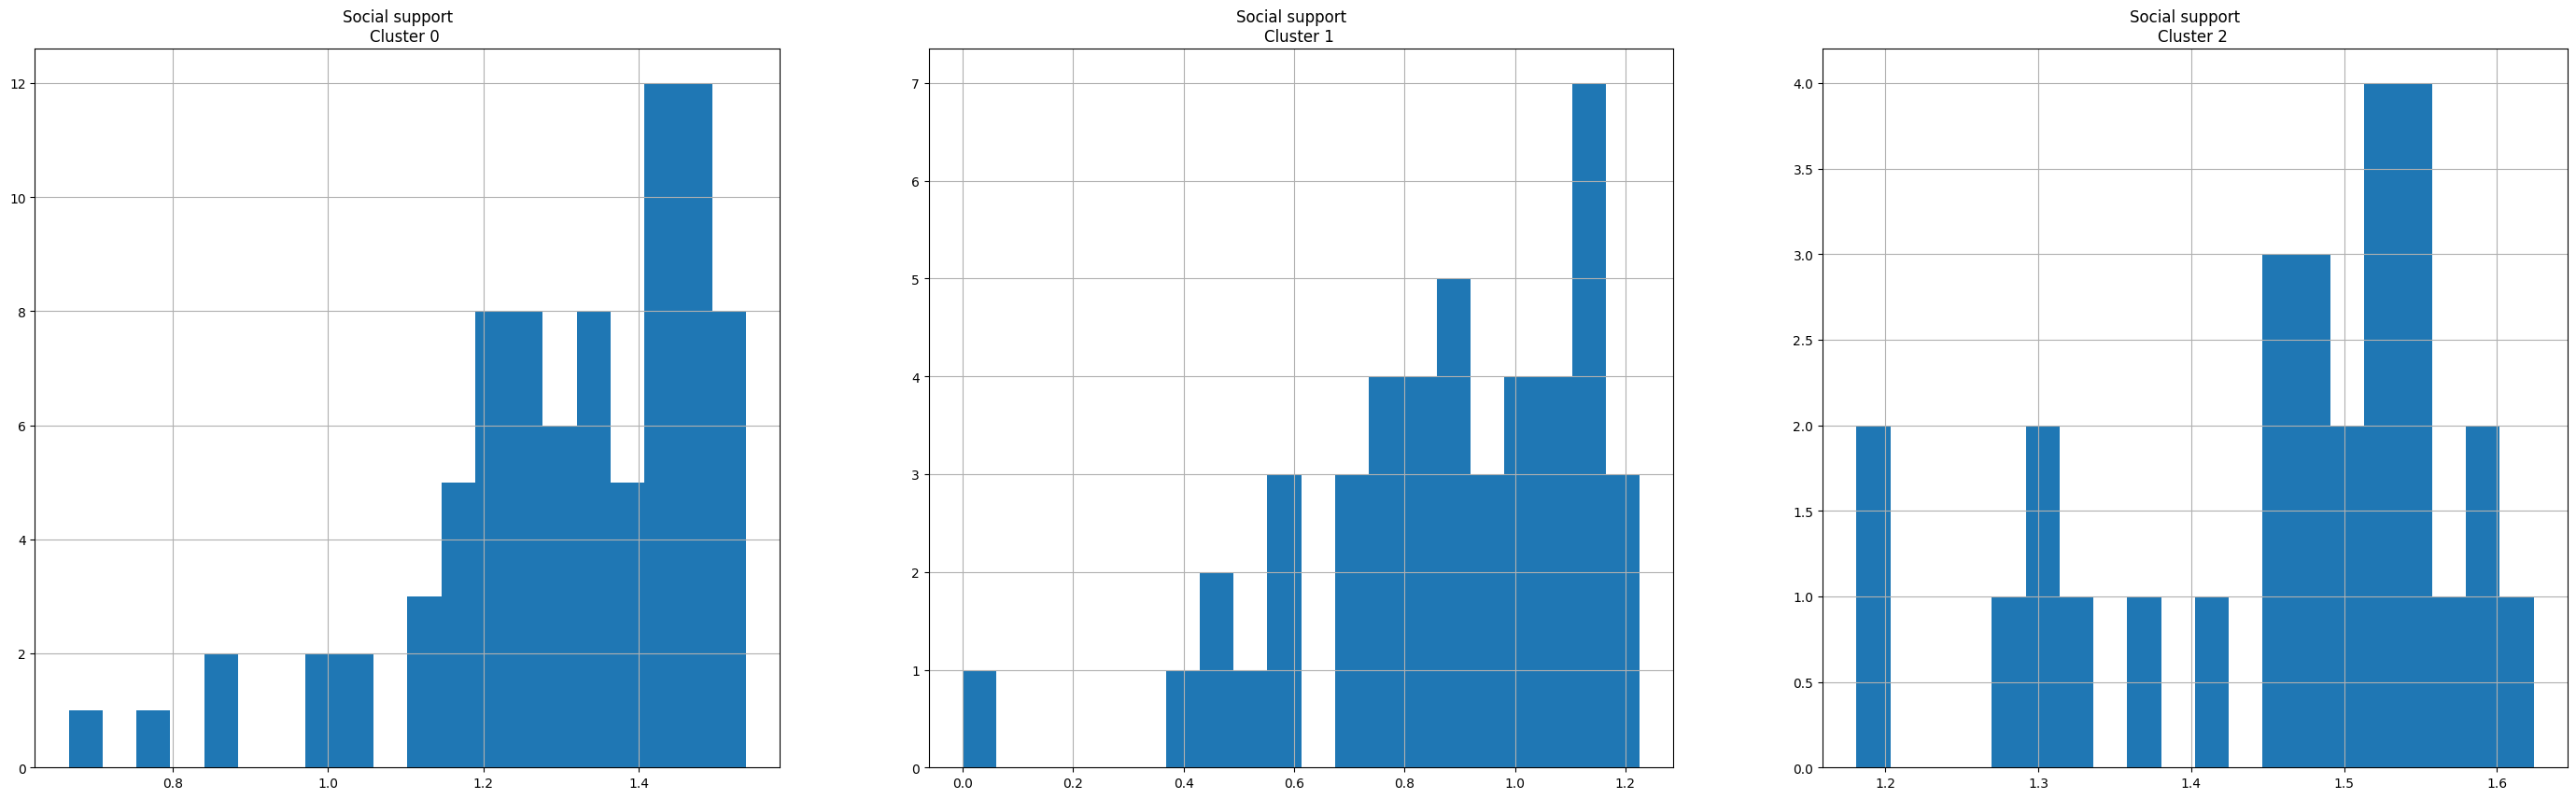

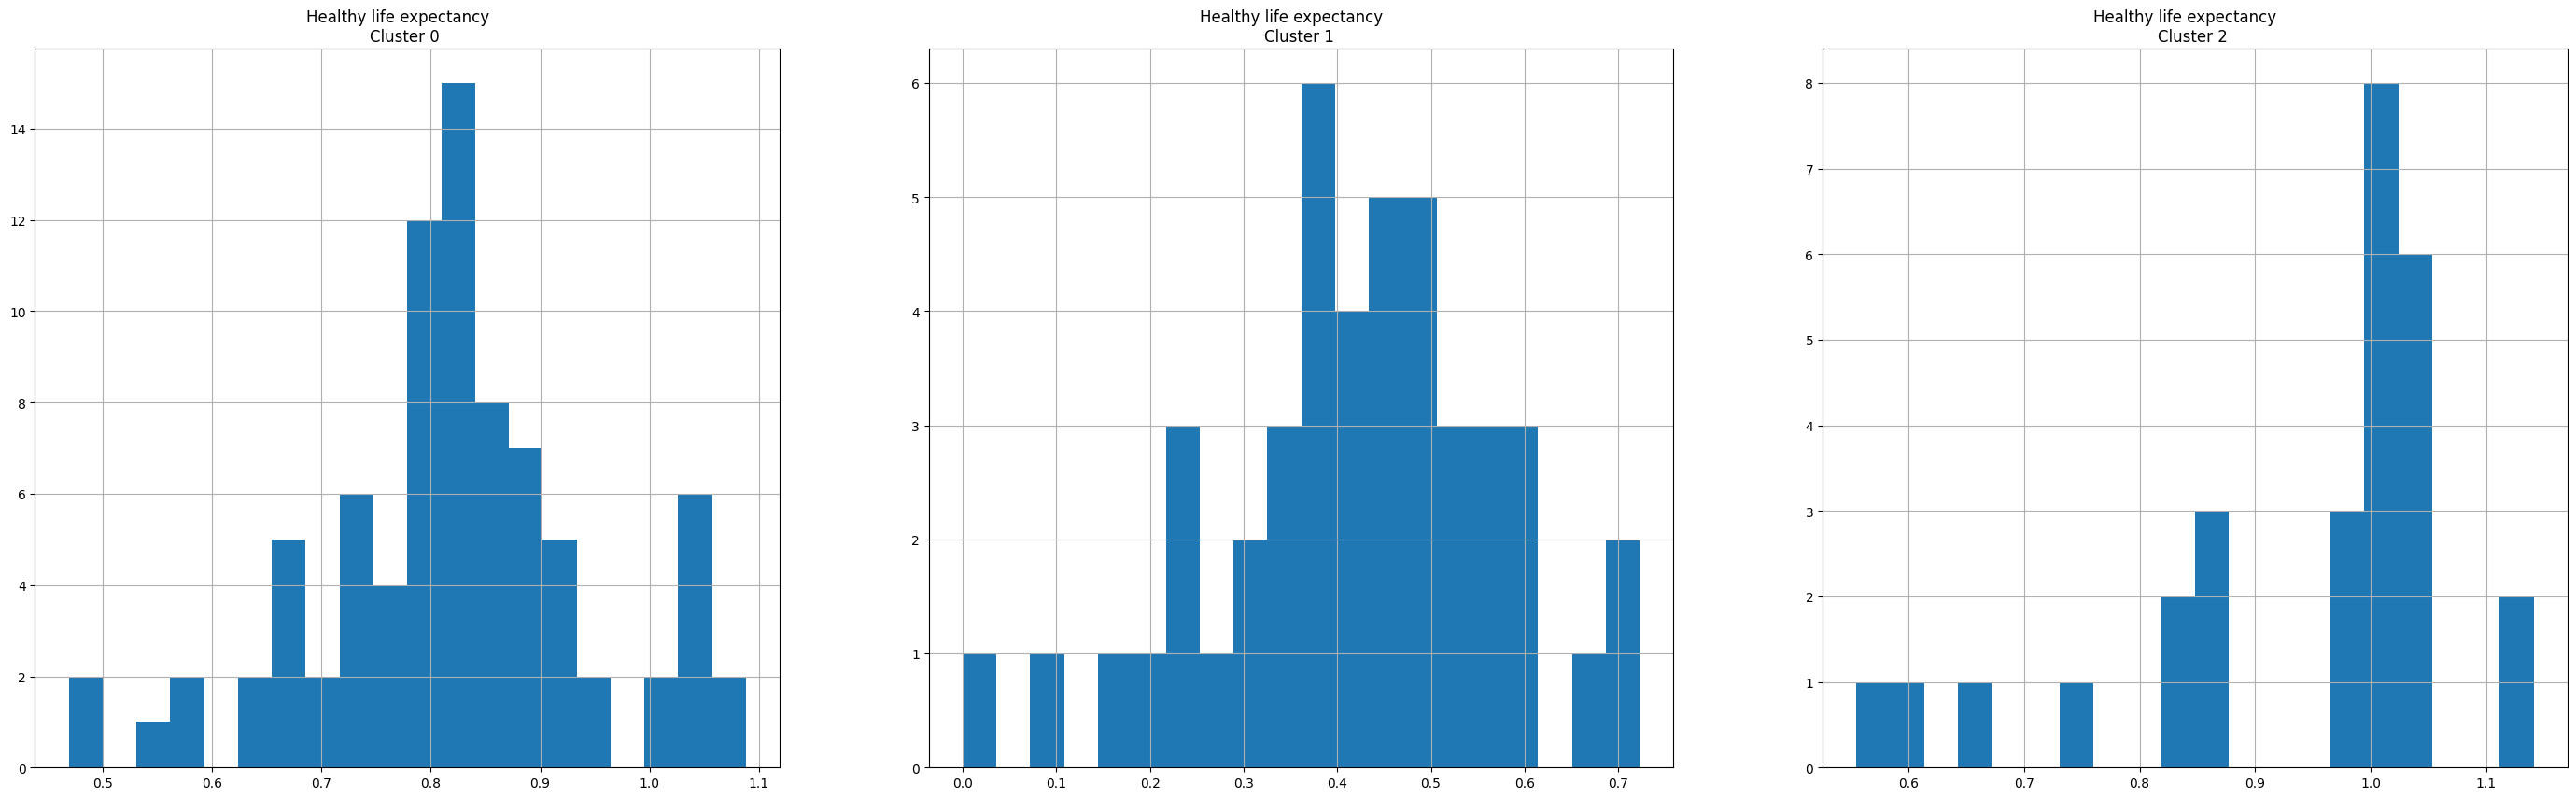

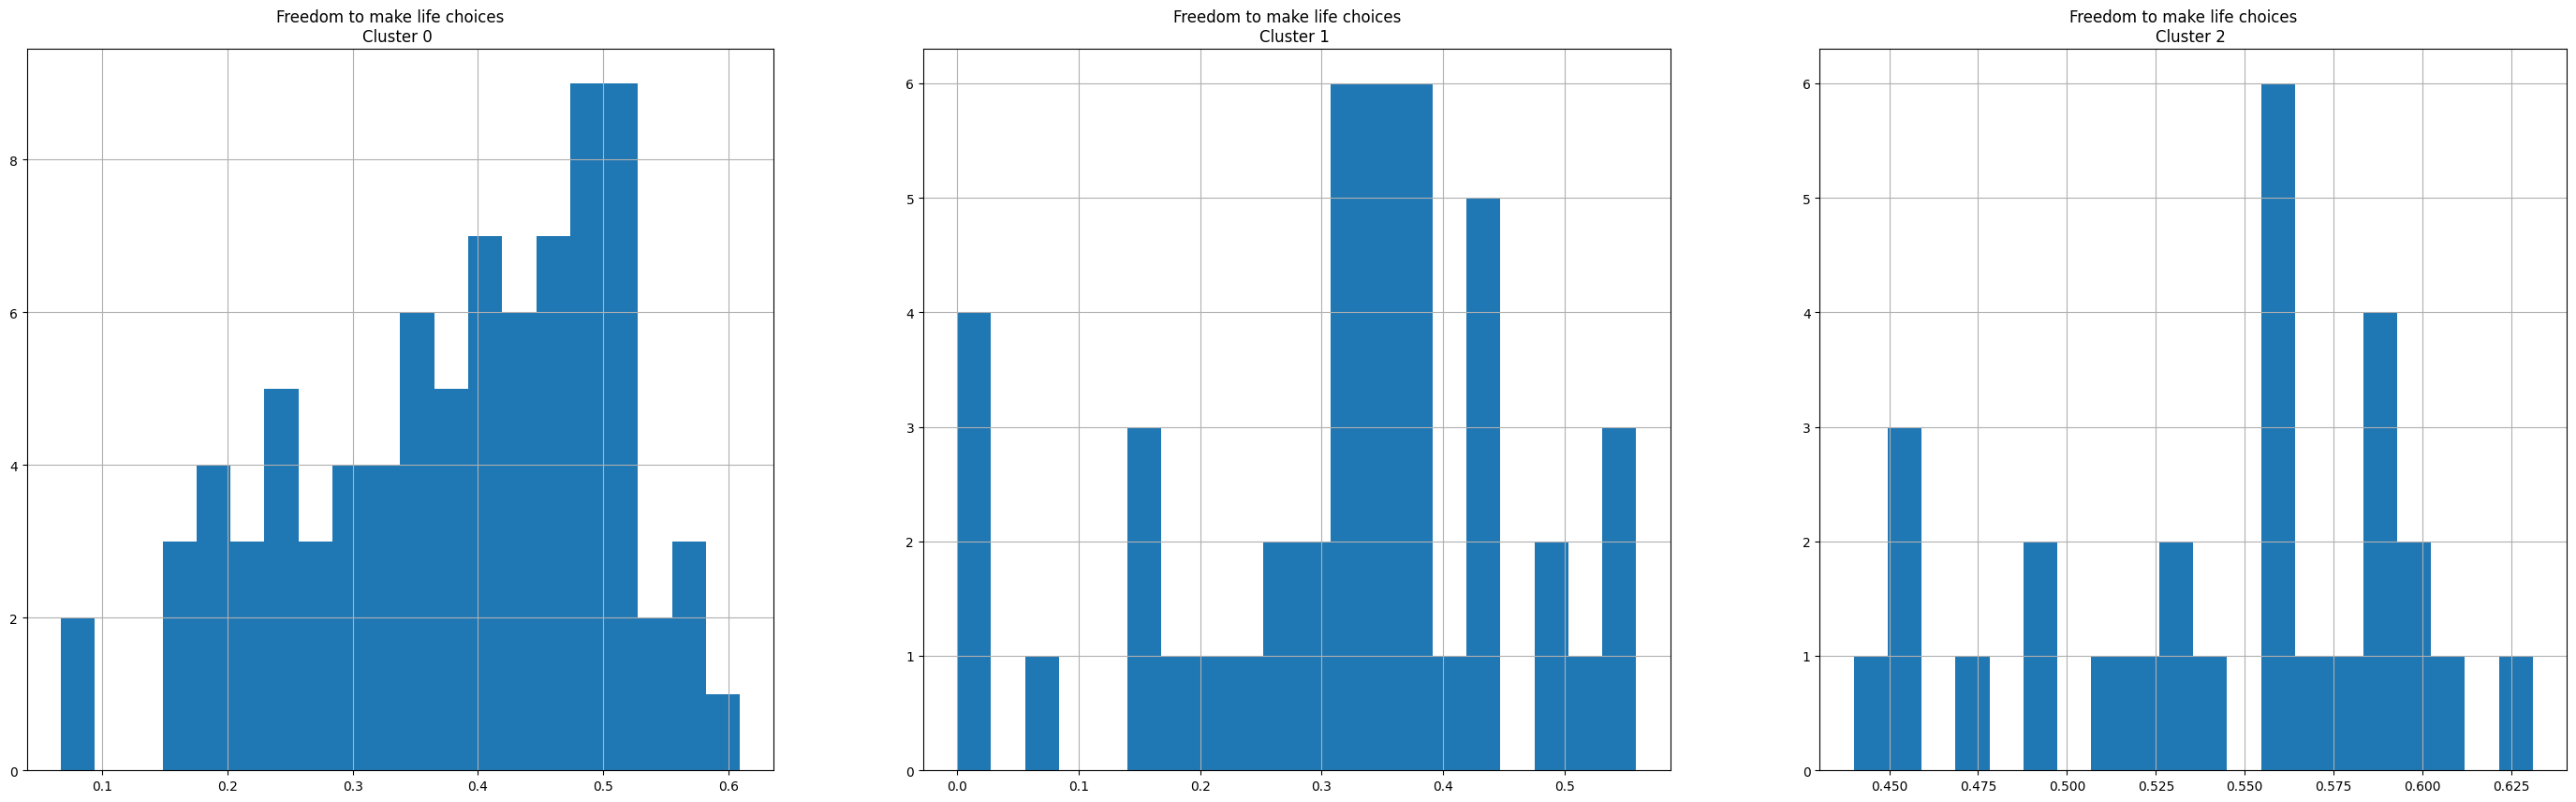

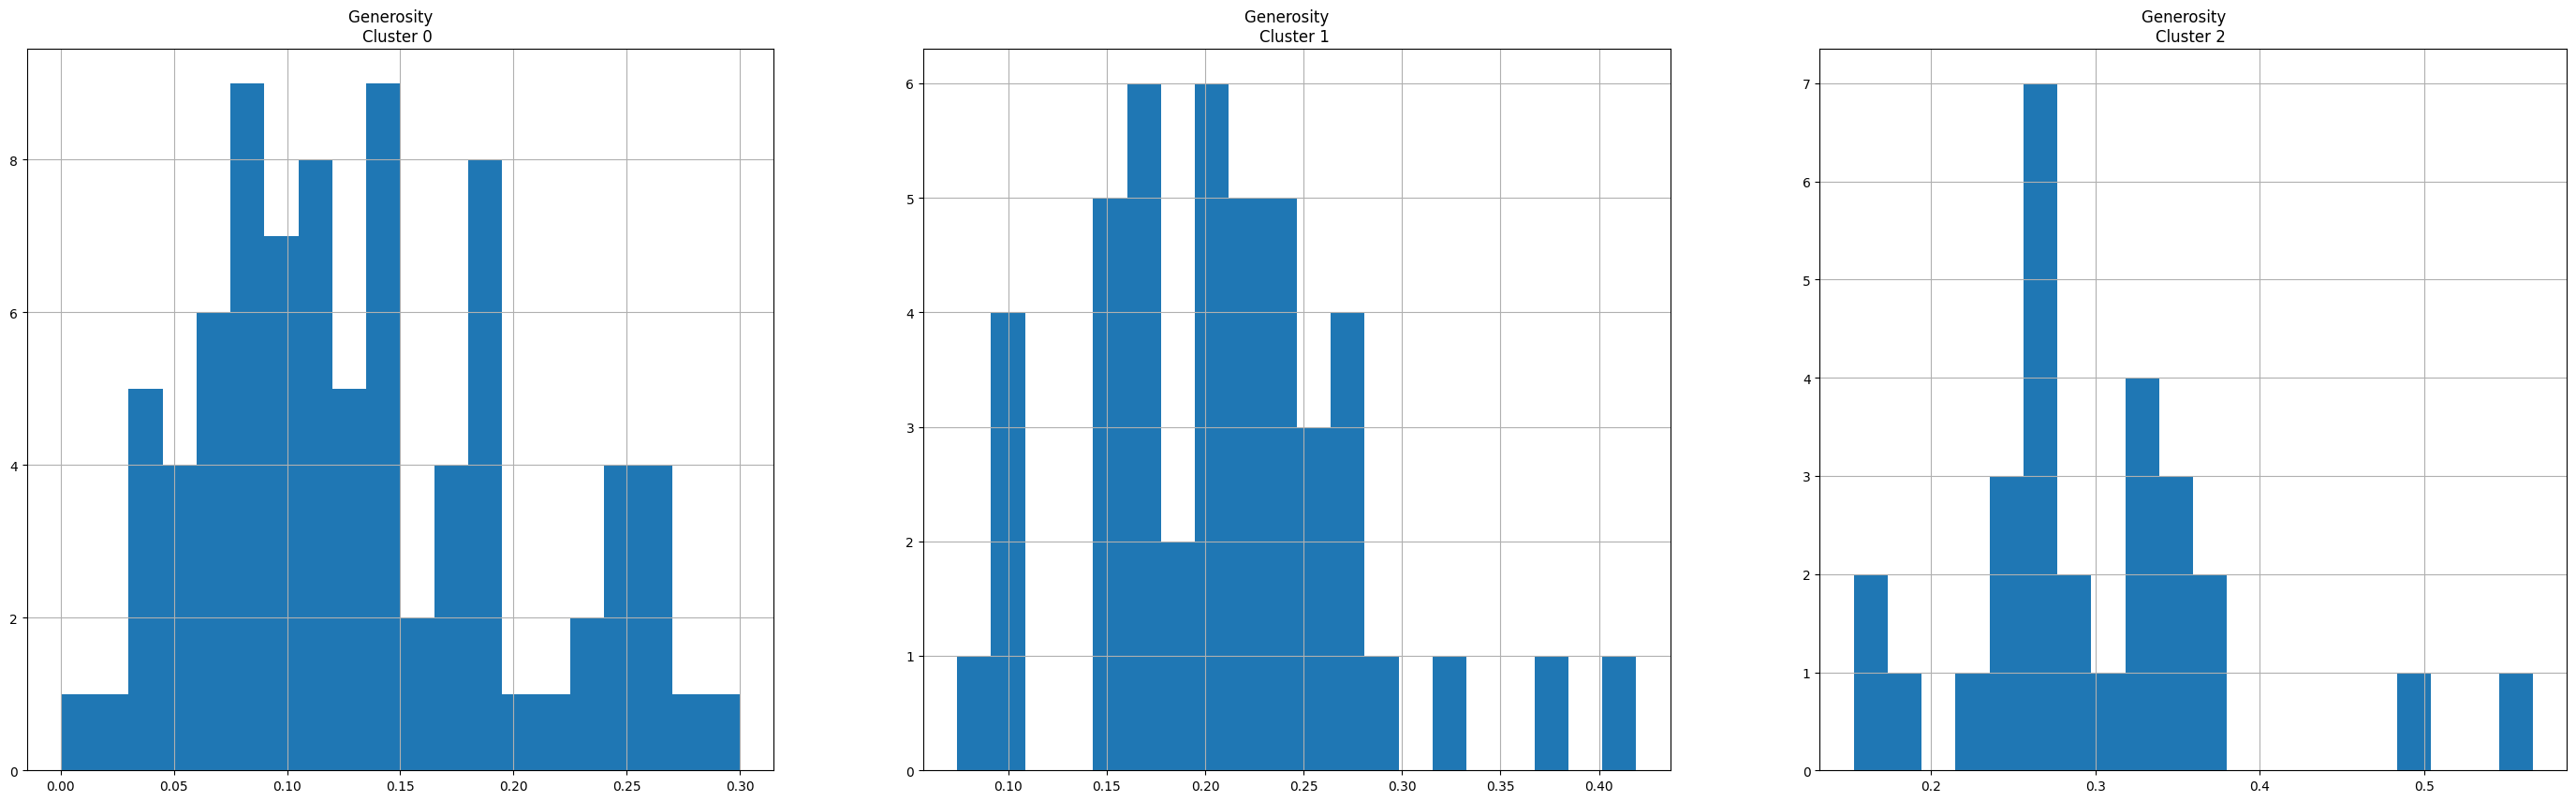

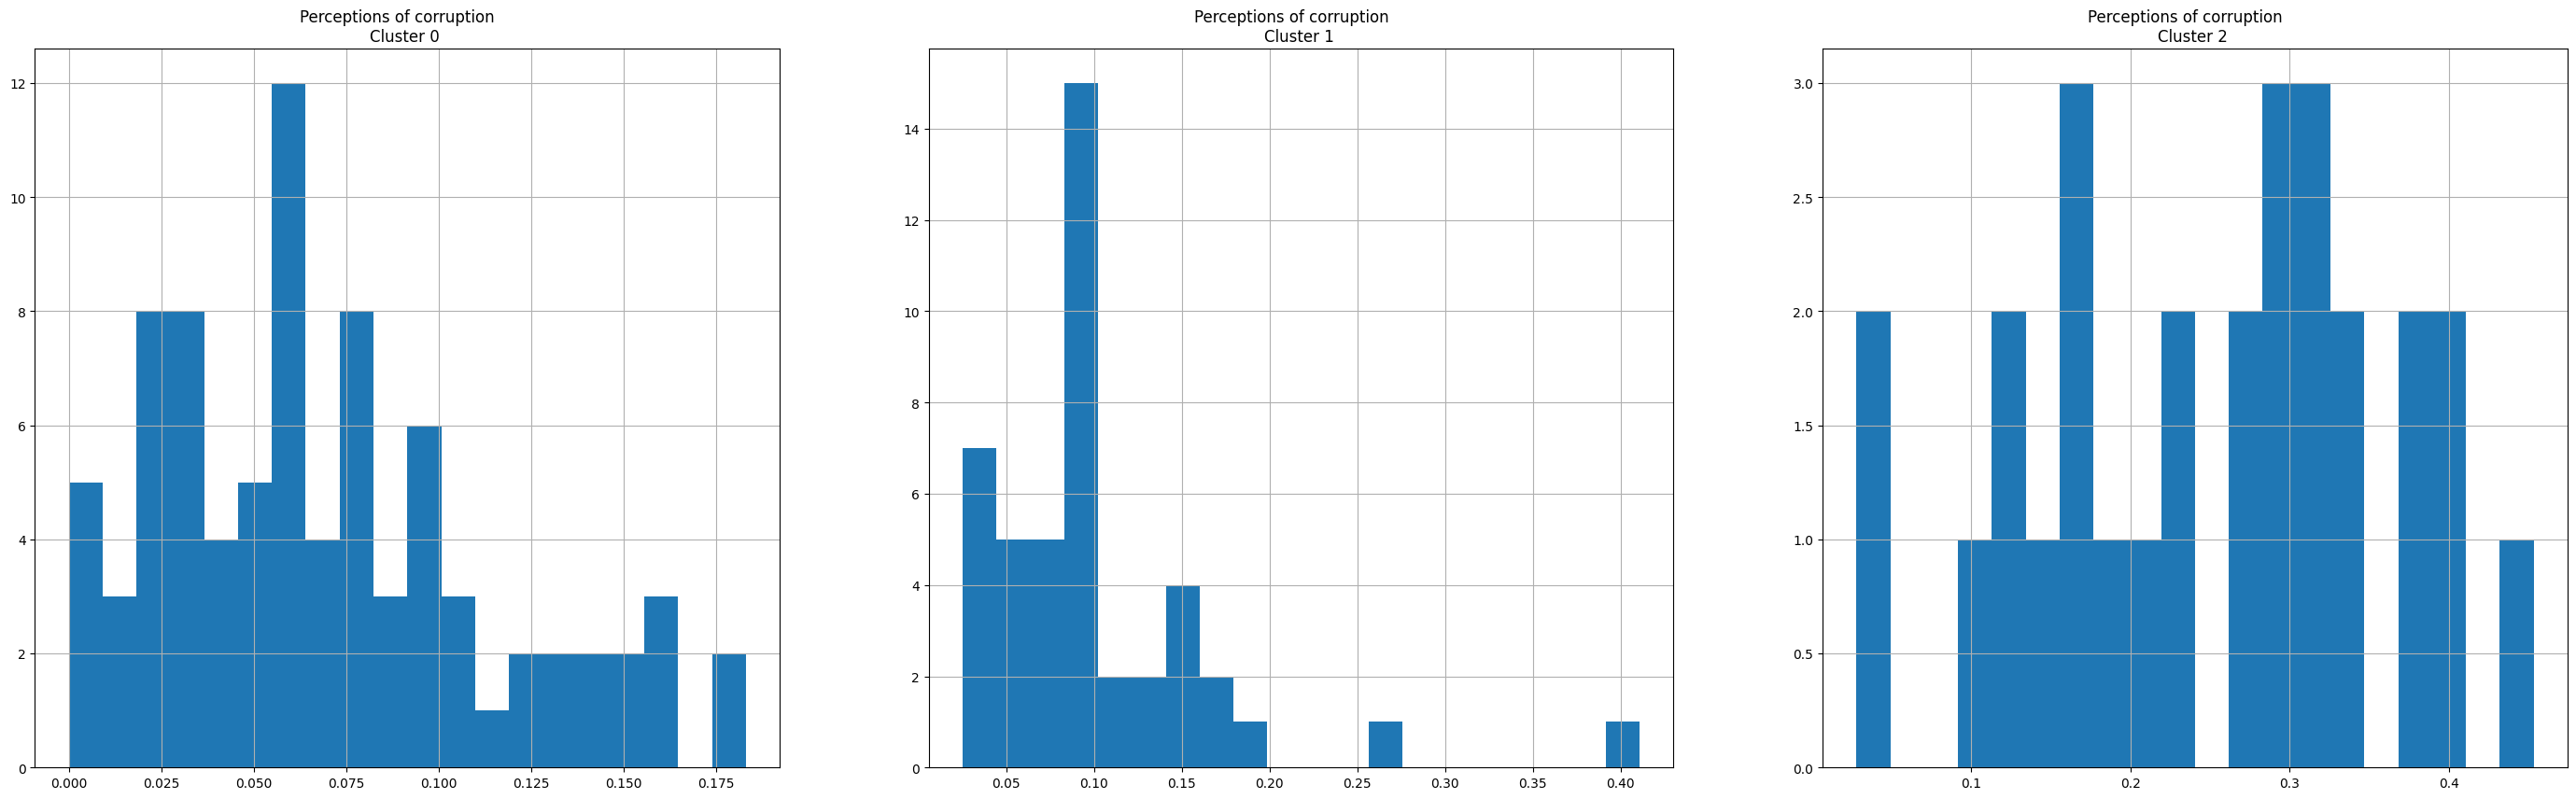

In [55]:
for i in df_seg.columns:
  plt.figure(figsize = (35, 10))
  for j in range(3):
    plt.subplot(1,3,j+1)
    cluster = happy_df_cluster[happy_df_cluster['cluster'] == j]
    cluster[i].hist(bins = 20)
    plt.title('{}    \nCluster {} '.format(i, j))

  plt.show()

In [56]:
# Plot the relationship between cluster and score

fig = px.scatter(happy_df_cluster, x = 'cluster', y = "Score",
           size = 'Overall rank', color = "Country or region", hover_name = "Country or region",
          trendline = "ols")

fig.update_layout(
    title_text = 'Happiness Score vs Cluster'
)
fig.show()

In [57]:
fig = px.scatter(happy_df_cluster, x='cluster', y='GDP per capita',
           size='Overall rank', color="Country or region", hover_name="Country or region",
          trendline= "ols")

fig.update_layout(
    title_text='GDP vs Clusters'
)
fig.show()

In [60]:
fig = px.scatter(happy_df_cluster, x='cluster', y='GDP per capita',
           size='Overall rank', color="Country or region", hover_name="Country or region",
          trendline= "ols")

fig.update_layout(
    title_text='GDP vs Clusters'
)
fig.show()

In [67]:
import plotly.express as px

fig = px.scatter(
    happy_df_cluster,
    x="GDP per capita",
    y="Perceptions of corruption",
    size="Score",
    color="cluster",
    hover_name="Country or region",
    size_max=40
)

fig.show()

In [72]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "colab"   # important in Colab

data = dict(
    type="choropleth",
    locations=happy_df_cluster["Country or region"],
    locationmode="country names",
    colorscale="RdYlGn",
    z=happy_df_cluster["cluster"],
    text=happy_df_cluster["Country or region"],
    colorbar={"title": "Clusters"},
)

layout = dict(
    title="Geographical Visualization of Clusters",
    geo=dict(showframe=True, projection={"type": "azimuthal equal area"}),
)

choromap3 = go.Figure(data=[data], layout=layout)
choromap3.show()

In [64]:
import pandas as pd
print(pd.__version__)

2.2.2


In [69]:
from plotly.offline import iplot, init_notebook_mode
init_notebook_mode(connected=True)